In [5]:
import os
import sys

# 1. Force Shutdown any existing Spark session to clear memory leaks
try:
    spark.stop()
except NameError:
    pass

# 2. Re-apply the Java 17+ / Arrow Memory Fix
# This MUST happen before SparkSession.builder
os.environ['PYSPARK_SUBMIT_ARGS'] = (
    "--packages io.delta:delta-spark_2.12:3.1.0 "
    "--conf spark.driver.extraJavaOptions='--add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED' "
    "--conf spark.executor.extraJavaOptions='--add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED' "
    "pyspark-shell"
)

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# 3. Initialize Spark with PyArrow enabled
spark = SparkSession.builder \
    .appName("CRISPR_EDA_Quality") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

print("Spark Session Reset. PyArrow & Java flags active.")

Spark Session Reset. PyArrow & Java flags active.


In [7]:
# Absolute path to your project data
path = "/home/dominickryan/Python_Scripts/crispr_project1/data/delta/gene_effects"

if os.path.exists(path):
    df = spark.read.format("delta").load(path)
    print(f"Success! Data loaded. Row count: {df.count():,}")
else:
    print(f"Error: Path not found at {path}")

[Stage 3:======================================================>  (48 + 2) / 50]

Success! Data loaded. Row count: 21,863,910


Transferring 50,000 rows via standard serialization (No Arrow)...


<Axes: xlabel='dependency_score', ylabel='Count'>

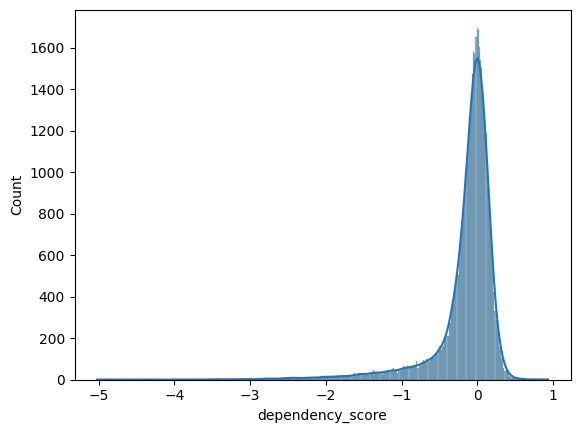

In [9]:
# 1. Stop the current broken session
spark.stop()

# 2. Re-initialize WITHOUT Arrow optimization
spark = SparkSession.builder \
    .appName("CRISPR_EDA_Quality") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .getOrCreate()

# 3. Load and Plot
path = "/home/dominickryan/Python_Scripts/crispr_project1/data/delta/gene_effects"
df = spark.read.format("delta").load(path)

print("Transferring 50,000 rows via standard serialization (No Arrow)...")
pdf = df.select("dependency_score").limit(50000).toPandas()

# The plot should work now
sns.histplot(pdf['dependency_score'], kde=True)

In [10]:
# Calculate the average dependency score for every gene across all 1,100+ cell lines
essential_genes = df.groupBy("gene_symbol") \
    .agg(F.mean("dependency_score").alias("avg_score")) \
    .sort("avg_score", ascending=True) \
    .limit(10)

print("Top 10 Essential Genes (Potential Therapeutic Targets):")
essential_genes.show()

Top 10 Essential Genes (Potential Therapeutic Targets):


[Stage 13:===========================================>              (3 + 1) / 4]

+-----------+-------------------+
|gene_symbol|          avg_score|
+-----------+-------------------+
|      RPL15|  -5.69716808889534|
|     SNRPD3| -5.470233093512841|
|        RAN|-4.2304578805482915|
|      HSPE1| -4.002866163943996|
|      PRIM2|-3.8722097954486174|
|      RPL17| -3.805104854117903|
|      RPL21|-3.3333497723656045|
|      SNRPF|-3.3301217656294355|
|       RPS8| -3.306135801306467|
|       RRM1| -3.290109518656659|
+-----------+-------------------+

